In [61]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 剩下所有业务代码

In [62]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ========== 数据与模型加载（沿用上一节的定义） ==========
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [63]:
CLASSES = test_dataset.classes

In [64]:
CLASSES

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [65]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [67]:
device

device(type='cuda')

In [68]:
model = CIFAR10CNN().to(device)

In [69]:
model.load_state_dict(torch.load("cifar10_cnn_weights.pth", map_location=device))

<All keys matched successfully>

In [70]:
model.eval()

CIFAR10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, k

In [71]:
@torch.no_grad()
def evaluate(model, loader, device):
    correct, total = 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return correct / total, np.array(all_preds), np.array(all_labels)

In [72]:
accuracy, preds, labels = evaluate(model, test_loader, device)

In [73]:
print(f"测试集准确率: {accuracy:.2%}")

测试集准确率: 86.25%


In [74]:
for i, cls in enumerate(CLASSES):
    mask = labels == i
    cls_acc = (preds[mask] == i).mean()
    print(f"  {cls:12s}: {cls_acc:.2%}")

  airplane    : 83.80%
  automobile  : 90.70%
  bird        : 76.00%
  cat         : 66.50%
  deer        : 86.60%
  dog         : 85.20%
  frog        : 94.10%
  horse       : 88.90%
  ship        : 94.00%
  truck       : 96.70%


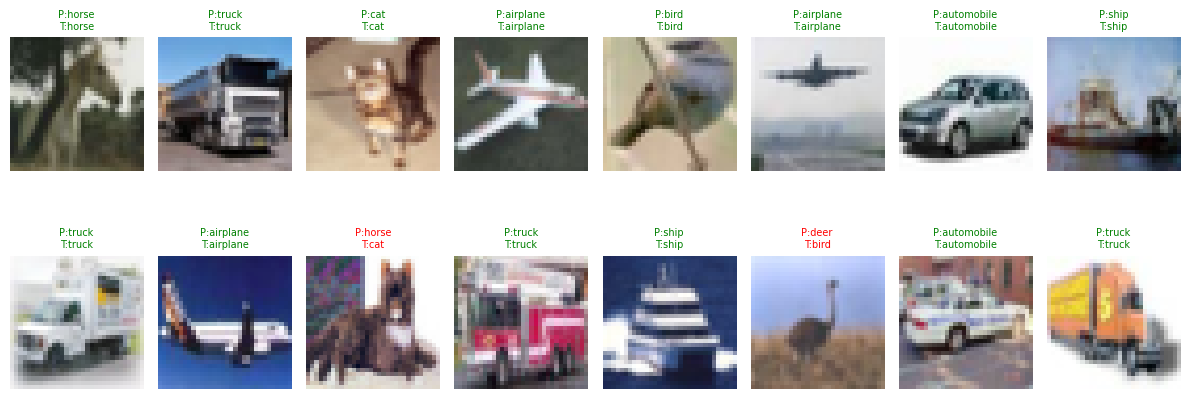

In [75]:
def imshow_grid(dataset, model, device, n=16):
    fig, axes = plt.subplots(2, n // 2, figsize=(12, 5))
    indices = np.random.choice(len(dataset), n, replace=False)

    for ax, idx in zip(axes.flat, indices):
        img_tensor, true_label = dataset[idx]
        with torch.no_grad():
            pred_label = model(img_tensor.unsqueeze(0).to(device)).argmax(1).item()

        img = img_tensor * torch.tensor(CIFAR10_STD).view(3, 1, 1)
        img = img + torch.tensor(CIFAR10_MEAN).view(3, 1, 1)

        img = img.permute(1, 2, 0).numpy().clip(0, 1)

        ax.imshow(img)
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f"P:{CLASSES[pred_label]}\nT:{CLASSES[true_label]}", fontsize=7, color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()

imshow_grid(test_dataset, model, device)